In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/app')
from database.db_connection import get_connection

conn = get_connection()
df = pd.read_sql("SELECT * FROM ml_features", conn)
conn.close()

print(f"Shape mới: {df.shape}")
print("--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---")

numeric_cols = ["lat", "lng", "area_m2", "price_vnd", "price_per_m2"]

bool_cols = [
    "has_wc", "has_ac", "has_parking", "has_kitchen", 
    "has_balcony", "has_security", "has_furniture", 
    "has_loft", "has_washer", "has_fridge", 
    "has_elevator", "has_basement", "free_hours", 
    "no_owner", "near_uni"
]

for col in numeric_cols + bool_cols:
    if col in df.columns:
        if col in bool_cols:
            count_ones = int(df[col].sum())
            print(f"  {col:20} : {count_ones} phòng có")
        else:
            valid_rows = df[col].count()
            print(f"  {col:20} : {valid_rows} / {len(df)} dòng hợp lệ")

Shape mới: (1497, 26)
--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---
  lat                  : 1497 / 1497 dòng hợp lệ
  lng                  : 1497 / 1497 dòng hợp lệ
  area_m2              : 1497 / 1497 dòng hợp lệ
  price_vnd            : 1497 / 1497 dòng hợp lệ
  price_per_m2         : 1497 / 1497 dòng hợp lệ
  has_wc               : 205 phòng có
  has_ac               : 1091 phòng có
  has_parking          : 385 phòng có
  has_kitchen          : 44 phòng có
  has_balcony          : 284 phòng có
  has_security         : 428 phòng có
  has_furniture        : 981 phòng có
  has_loft             : 478 phòng có
  has_washer           : 950 phòng có
  has_fridge           : 755 phòng có
  has_elevator         : 516 phòng có
  has_basement         : 780 phòng có
  free_hours           : 1182 phòng có
  no_owner             : 1042 phòng có
  near_uni             : 301 phòng có


/tmp/ipykernel_5720/1206943785.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ml_features", conn)


In [2]:

df_clean = df.copy()

# Lọc giá và diện tích hợp lý
df_clean = df_clean[df_clean["price_vnd"].between(500_000, 20_000_000)]
df_clean = df_clean[df_clean["area_m2"].between(6, 80)]
df_clean = df_clean[df_clean["price_per_m2"].between(50_000, 500_000)]

# Bỏ cột không dùng
DROP_COLS = ["listing_id", "scraped_at", "posted_at_raw",
             "district_name", "price_per_m2", "room_type", "posted_at"]
df_clean = df_clean.drop(columns=[c for c in DROP_COLS if c in df_clean.columns])


df_clean["log_price"] = np.log1p(df_clean["price_vnd"])


print(f"Shape sau clean: {df_clean.shape}")
print(f"Null còn lại:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}")

Shape sau clean: (1360, 21)
Null còn lại:
Series([], dtype: int64)


Train: 1088 | Test: 272


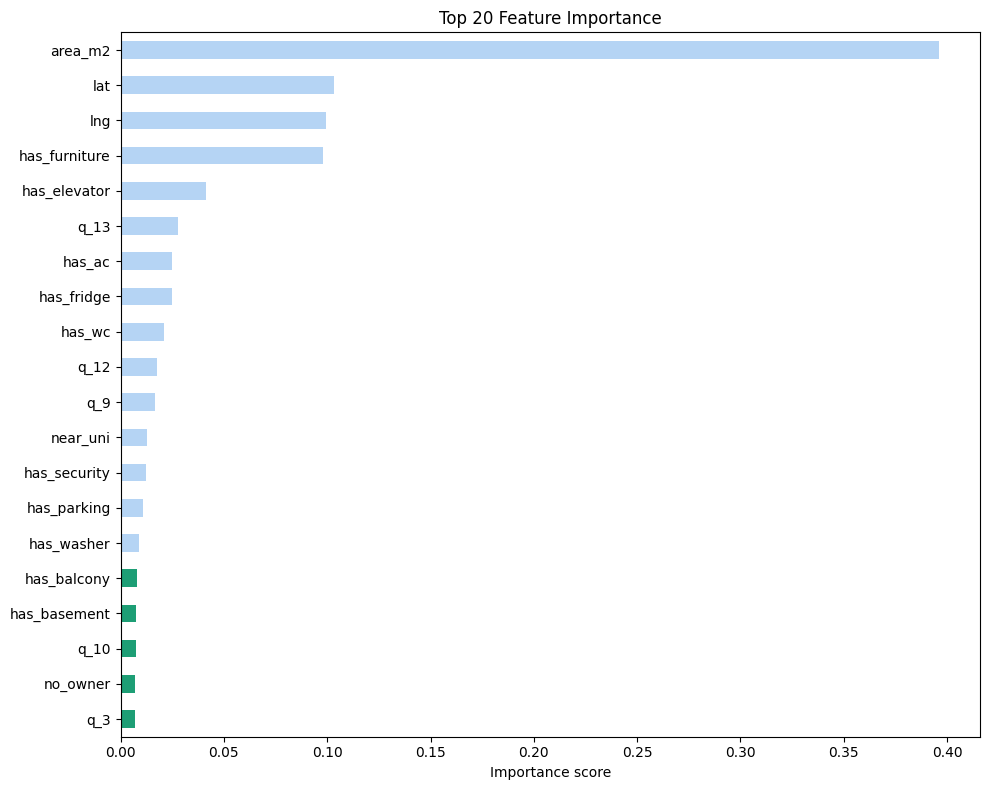


Feature mạnh (importance > 0.01): 14
  area_m2                   : 0.3961
  lat                       : 0.1032
  lng                       : 0.0995
  has_furniture             : 0.0978
  has_elevator              : 0.0413
  q_13                      : 0.0278
  has_ac                    : 0.0249
  has_fridge                : 0.0248
  has_wc                    : 0.0210
  q_12                      : 0.0178
  q_9                       : 0.0168
  near_uni                  : 0.0129
  has_security              : 0.0121
  has_parking               : 0.0110


In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# One-hot encode district_id
df_enc = pd.get_dummies(df_clean, columns=["district_id"], prefix="q", drop_first=True)

FEATURE_COLS = [c for c in df_enc.columns
                if c not in ["price_vnd", "log_price"]]

# Điền null lat/lng bằng trung vị (một số listing geocode thất bại)
for col in ["lat", "lng"]:
    df_enc[col] = df_enc[col].fillna(df_enc[col].median())

X = df_enc[FEATURE_COLS]
y = df_enc["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Train nhanh để xem feature importance
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

# Vẽ top 20 feature quan trọng nhất
importance = pd.Series(gb.feature_importances_, index=FEATURE_COLS)
top20 = importance.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1D9E75" if i >= 15 else "#B5D4F4" for i in range(len(top20))]
top20.plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Top 20 Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("/app/data/feature_importance_v2.png", dpi=150)
plt.show()
print
# Chọn feature có importance > 0.01
STRONG_FEATURES = importance[importance > 0.01].index.tolist()
print(f"\nFeature mạnh (importance > 0.01): {len(STRONG_FEATURES)}")
for f in sorted(STRONG_FEATURES, key=lambda x: importance[x], reverse=True):
    print(f"  {f:25} : {importance[f]:.4f}")

In [4]:
all_features_sorted = importance.sort_values(ascending=False)

print(f"\n--- BẢNG XẾP HẠNG TOÀN BỘ {len(all_features_sorted)} FEATURES ---")
for f, val in all_features_sorted.items():
    # In ra với định dạng căn lề đẹp mắt
    print(f"  {f:25} : {val:.4f}")



--- BẢNG XẾP HẠNG TOÀN BỘ 39 FEATURES ---
  area_m2                   : 0.3961
  lat                       : 0.1032
  lng                       : 0.0995
  has_furniture             : 0.0978
  has_elevator              : 0.0413
  q_13                      : 0.0278
  has_ac                    : 0.0249
  has_fridge                : 0.0248
  has_wc                    : 0.0210
  q_12                      : 0.0178
  q_9                       : 0.0168
  near_uni                  : 0.0129
  has_security              : 0.0121
  has_parking               : 0.0110
  has_washer                : 0.0091
  has_balcony               : 0.0078
  has_basement              : 0.0076
  q_10                      : 0.0074
  no_owner                  : 0.0070
  q_3                       : 0.0069
  has_loft                  : 0.0055
  free_hours                : 0.0054
  q_19                      : 0.0052
  q_8                       : 0.0037
  has_kitchen               : 0.0034
  q_17                      : 0.

In [5]:

print(df[['district_id', 'district_name']].drop_duplicates().sort_values('district_id'))

     district_id district_name
92             1        Quận 1
11             2        Quận 2
1              3        Quận 3
211            4        Quận 4
108            5        Quận 5
59             6        Quận 6
36             7        Quận 7
31             8        Quận 8
9              9        Quận 9
32            10       Quận 10
97            11       Quận 11
4             12       Quận 12
7             13    Bình Thạnh
23            14      Bình Tân
42            15        Gò Vấp
69            16     Phú Nhuận
2             17      Tân Bình
0             18       Tân Phú
13            19       Thủ Đức
106           20    Bình Chánh
380           21       Hóc Môn
88            22        Nhà Bè
501           24        Củ Chi


In [6]:
import joblib, os

os.makedirs("/app/models", exist_ok=True)

# Dùng chỉ feature mạnh
X_train_final = X_train[STRONG_FEATURES]
X_test_final  = X_test[STRONG_FEATURES]

# Train model cuối
gb_final = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb_final.fit(X_train_final, y_train)

from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_pred      = gb_final.predict(X_test_final)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

r2   = r2_score(y_test_real, y_pred_real)
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))

print(f"=== KẾT QUẢ MODEL V2 ===")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"MAE  : {mae/1e6:.2f} triệu VNĐ")
print(f"RMSE : {rmse/1e6:.2f} triệu VNĐ")

# Lưu model và metadata
joblib.dump(gb_final,       "/app/models/best_model_v2.pkl")
joblib.dump(STRONG_FEATURES,"/app/models/feature_cols_v2.pkl")
joblib.dump({
    "r2": r2, "mae": mae, "rmse": rmse,
    "n_train": len(X_train_final),
    "n_test":  len(X_test_final),
    "n_features": len(STRONG_FEATURES),
}, "/app/models/model_metrics_v2.pkl")

print(f"\nĐã lưu model → /app/models/best_model_v2.pkl")
print(f"Sẵn sàng cho bước tiếp theo!")

=== KẾT QUẢ MODEL V2 ===
R²   : 0.4975  (49.8% variance explained)
MAE  : 0.67 triệu VNĐ
RMSE : 0.95 triệu VNĐ

Đã lưu model → /app/models/best_model_v2.pkl
Sẵn sàng cho bước tiếp theo!


In [7]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

# Nhập các "tuyển thủ"
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("🚀 Bắt đầu quá trình Model Benchmarking...\n")

# Định nghĩa từ điển chứa các mô hình với cấu hình cơ bản/tương đương nhau
models = {
    "Ridge (Baseline)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    "GBR (Current)": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, n_jobs=-1, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=300, depth=4, learning_rate=0.05, verbose=0, random_seed=42)
}

results = []

# Vòng lặp cho các mô hình lên sàn đấu
for name, model in models.items():
    start_time = time.time()
    
    # 1. Huấn luyện (Train)
    model.fit(X_train_final, y_train)
    
    # 2. Dự đoán (Predict)
    y_pred = model.predict(X_test_final)
    
    # 3. Đưa giá trị về VND thực tế (vì bạn đang dùng log1p)
    y_pred_real = np.expm1(y_pred)
    y_test_real = np.expm1(y_test)
    
    # 4. Chấm điểm
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))
    
    train_time = time.time() - start_time
    
    # Lưu kết quả
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE (Tr VNĐ)": mae / 1e6,
        "RMSE (Tr VNĐ)": rmse / 1e6,
        "Time (s)": train_time
    })

# In bảng xếp hạng
df_results = pd.DataFrame(results)
# Sắp xếp theo R2 giảm dần (điểm cao nhất lên đầu)
df_results = df_results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("🏆 BẢNG XẾP HẠNG CÁC MÔ HÌNH:")
print("-" * 65)
# Format số cho đẹp mắt khi in
format_dict = {"R2 Score": "{:.4f}", "MAE (Tr VNĐ)": "{:.2f}", "RMSE (Tr VNĐ)": "{:.2f}", "Time (s)": "{:.2f}"}
print(df_results.style.format(format_dict).to_string())
print("-" * 65)

🚀 Bắt đầu quá trình Model Benchmarking...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 1088, number of used features: 14
[LightGBM] [Info] Start training from score 15.094672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

In [8]:
import os
import joblib
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

print("🚀 Bắt đầu quá trình ép xung (Hyperparameter Tuning) cho CatBoost...")

# 1. Khởi tạo mô hình cơ sở (ẩn log cho đỡ rác màn hình)
cb_base = CatBoostRegressor(loss_function='RMSE', verbose=0, random_seed=42)

# 2. Định nghĩa không gian siêu tham số (Hyperparameter Space)
param_dist = {
    'iterations': [300, 500, 800, 1000],       # Số lượng cây
    'learning_rate': [0.01, 0.03, 0.05, 0.1],  # Bước nhảy học tập
    'depth': [4, 6, 8],                        # Độ sâu của cây (tránh để quá sâu gây overfit)
    'l2_leaf_reg': [1, 3, 5, 7, 9]             # Trọng số phạt L2 (vũ khí xịn nhất để chống học vẹt)
}

# 3. Cấu hình tìm kiếm ngẫu nhiên (chỉ test 20 cấu hình x 3 folds = 60 lần chạy)
random_search = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=param_dist,
    n_iter=20,           # Số lượng cấu hình ngẫu nhiên sẽ test
    cv=3,                # Chia tập train thành 3 phần để cross-validation
    scoring='neg_mean_absolute_error', # Tối ưu hóa dựa trên MAE
    n_jobs=-1,           # Dùng 100% CPU để chạy nhanh nhất có thể
    random_state=42,
    verbose=1            # Hiển thị thanh tiến trình
)

# 4. Bắt đầu Train
random_search.fit(X_train_final, y_train)

# Lấy ra "Nhà vô địch"
best_cb = random_search.best_estimator_

print("\n🏆 KẾT QUẢ TUNING:")
print(f"Bộ tham số đỉnh nhất: {random_search.best_params_}")

# 5. Đánh giá lại trên tập Test xem có vượt mốc R2 0.50 lúc nãy không
y_pred = best_cb.predict(X_test_final)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

r2 = r2_score(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))

print("-" * 30)
print(f"R² Tối ưu  : {r2:.4f}")
print(f"MAE Tối ưu : {mae/1e6:.2f} triệu VNĐ")
print(f"RMSE       : {rmse/1e6:.2f} triệu VNĐ")
print("-" * 30)

# 6. Lưu model theo ĐỊNH DẠNG CHUẨN CỦA CATBOOST (.cbm)
os.makedirs("/app/models", exist_ok=True)

# LƯU Ý KỸ: Không dùng joblib.dump cho CatBoost model
best_cb.save_model("/app/models/best_model_v3.cbm") 
joblib.dump(STRONG_FEATURES, "/app/models/feature_cols_v3.pkl")

print("✅ Đã lưu model xịn nhất -> /app/models/best_model_v3.cbm")

🚀 Bắt đầu quá trình ép xung (Hyperparameter Tuning) cho CatBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 KẾT QUẢ TUNING:
Bộ tham số đỉnh nhất: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6}
------------------------------
R² Tối ưu  : 0.5243
MAE Tối ưu : 0.65 triệu VNĐ
RMSE       : 0.92 triệu VNĐ
------------------------------
✅ Đã lưu model xịn nhất -> /app/models/best_model_v3.cbm


In [9]:
df_dropped = df[~df.index.isin(df_clean.index)]
print(f"Số dòng bị loại bỏ: {len(df_dropped)}")
print("\nDanh sách 10 phòng trọ 'dị biệt' bị xóa:")
# In ra xem giá và diện tích của chúng
print(df_dropped[["price_vnd", "area_m2", "price_per_m2"]].head(10))

Số dòng bị loại bỏ: 137

Danh sách 10 phòng trọ 'dị biệt' bị xóa:
     price_vnd  area_m2   price_per_m2
8      1800000    100.0   18000.000000
11    70000000     75.0  933333.333333
80     1700000    100.0   17000.000000
94     1300000     35.0   37142.857143
95     1700000     35.0   48571.428571
96     1700000     35.0   48571.428571
100    1500000     35.0   42857.142857
101    1200000     30.0   40000.000000
105    2200000    100.0   22000.000000
107    1200000     30.0   40000.000000


/tmp/ipykernel_5720/3417655534.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count_goc = pd.read_sql("SELECT COUNT(*) as total FROM phong_tro", conn)


ProgrammingError: ('42S02', "[42S02] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Invalid object name 'phong_tro'. (208) (SQLExecDirectW)")